In [1]:
!pip install -q transformers==4.45.2
!pip install -q peft==0.14.0
!pip install -q accelerate bitsandbytes pillow
!pip install -q einops addict easydict

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00


In [2]:
import sys
from huggingface_hub import snapshot_download

MODEL_DIR = "./deepseek_ocr2"

snapshot_download(
    repo_id="deepseek-ai/DeepSeek-OCR-2",
    local_dir=MODEL_DIR
)

if MODEL_DIR not in sys.path:
    sys.path.insert(0, MODEL_DIR)

print("✅ Base model downloaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

conversation.py: 0.00B [00:00, ?B/s]

configuration_deepseek_v2.py: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

processor_config.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

✅ Base model downloaded


In [4]:
import torch
from transformers import AutoModel, AutoTokenizer
from peft import PeftModel

base_model = AutoModel.from_pretrained(
    MODEL_DIR,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
    use_safetensors=True,
)

model = PeftModel.from_pretrained(
    base_model,
    "zahidazam714/khowar-ocr-v0.1"
)

model = model.to("cuda:0")
model.eval()

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_DIR,
    trust_remote_code=True,
    use_fast=True,
)

print("✅ Model ready")

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR2. This is not supported for all configurations of models and can yield errors.


adapter_config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✅ Model ready


In [5]:
# =========================================
# PATCH ISSUE
# =========================================

import os

file_path = os.path.expanduser(
    "~/.cache/huggingface/modules/transformers_modules/deepseek_ocr2/modeling_deepseekocr2.py"
)

with open(file_path, 'r') as f:
    content = f.read()

if 'inputs_embeds = inputs_embeds.clone()  # patched' not in content:
    content = content.replace(
        'inputs_embeds[idx].masked_scatter_(',
        'inputs_embeds = inputs_embeds.clone()  # patched\n        inputs_embeds[idx].masked_scatter_('
    )

    with open(file_path, 'w') as f:
        f.write(content)

print("✅ Patched")

✅ Patched


In [6]:
"/content/drive/MyDrive/MyDrive/khowar_deepseek.zip"

'/content/drive/MyDrive/MyDrive/khowar_deepseek.zip'

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

zip_path = "/content/drive/MyDrive/MyDrive/khowar_deepseek.zip"

print(os.path.exists(zip_path))

True


In [10]:
import zipfile

extract_path = "/content/khowar_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted")

✅ Extracted


In [47]:
import json
import random
from PIL import Image

jsonl_path = "/content/khowar_dataset/train.jsonl"

samples = []

with open(jsonl_path, "r", encoding="utf-8") as f:
    for line in f:
        samples.append(json.loads(line))

sample = random.choice(samples)

image_rel_path = sample["messages"][0]["content"][0]["image"]
ground_truth = sample["messages"][1]["content"]

image_path = os.path.join(
    "/content/khowar_dataset",
    image_rel_path
)

print("✅ Image:", image_path)
print(" GROUND TRUTH\n")
print(ground_truth)



✅ Image: /content/khowar_dataset/aug_images/img_07550_aug2.png
 GROUND TRUTH

وا کا لودیکو سف ای بیتی کی ہوسیتانی ہسے ہے محفلہ مزہ گنیک جوݰونو بوئے۔


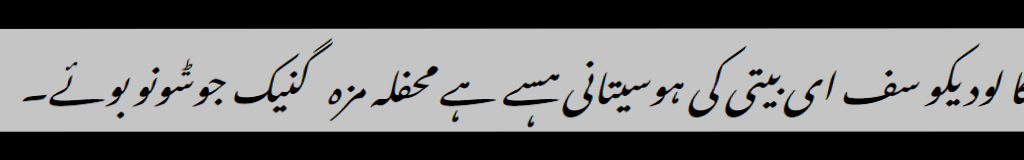

In [48]:
from PIL import Image

image = Image.open(image_path).convert("RGB")

display(image)

In [49]:
from io import StringIO
import sys

# Capture stdout
old_stdout = sys.stdout
sys.stdout = mystdout = StringIO()

_ = model.infer(
    tokenizer,
    prompt="<image>\nFree OCR.",
    image_file=image_path,
    output_path="/content/output",
    base_size=1024,
    image_size=768,
    crop_mode=True,
    save_results=False,
)

# Restore stdout
sys.stdout = old_stdout

prediction = mystdout.getvalue().strip()

print("\n===== GROUND TRUTH =====\n")
print(ground_truth)

print("\n===== PREDICTED OUTPUT =====\n")
print(prediction)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



===== GROUND TRUTH =====

وا کا لودیکو سف ای بیتی کی ہوسیتانی ہسے ہے محفلہ مزہ گنیک جوݰونو بوئے۔

===== PREDICTED OUTPUT =====

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([6, 144, 1280])
ہے اوا کیکو سف ای ہیتی کی ہوسیتانی ہسے ہے محفلہ مہ دہ گنیک جوݰونو بوئے۔


## CER Checking

In [ ]:
!pip install -q jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 108.5 MB/s eta 0:00:00


In [ ]:
import json
import random
import os
from jiwer import cer
from PIL import Image
from tqdm import tqdm
from io import StringIO
import sys

In [ ]:
jsonl_path = "/content/khowar_dataset/val.jsonl"

samples = []

with open(jsonl_path, "r", encoding="utf-8") as f:
    for line in f:
        samples.append(json.loads(line))

print("Validation samples:", len(samples))

# =========================================
# EVALUATE
# =========================================

all_cers = []

NUM_SAMPLES = 50   # increase later

for sample in tqdm(samples[:NUM_SAMPLES]):

    image_rel_path = sample["messages"][0]["content"][0]["image"]

    ground_truth = sample["messages"][1]["content"]

    image_path = os.path.join(
        "/content/khowar_dataset",
        image_rel_path
    )

    # Capture stdout
    old_stdout = sys.stdout
    sys.stdout = mystdout = StringIO()

    try:
        _ = model.infer(
            tokenizer,
            prompt="<image>\nFree OCR.",
            image_file=image_path,
            output_path="/content/output",
            base_size=1024,
            image_size=768,
            crop_mode=True,
            save_results=False,
        )

        sys.stdout = old_stdout

        prediction = mystdout.getvalue().strip()

        sample_cer = cer(ground_truth, prediction)

        all_cers.append(sample_cer)

    except Exception as e:

        sys.stdout = old_stdout
        print("Error:", e)

# =========================================
# FINAL SCORE
# =========================================

avg_cer = sum(all_cers) / len(all_cers)

print("\n========================")
print("AVERAGE CER:", avg_cer)
print("========================")

Validation samples: 1996


  0%|          | 0/50 [00:00<?, ?it/s]The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
  2%|▏         | 1/50 [00:06<05:41,  6.97s/it]The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
  4%|▍         | 2/50 [00:12<04:46,  5.97s/it]The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
  6%|▌         | 3/50 [00:18<04:48,  6.15s/it]The attention mask and the pad token id were not set. As a consequence, yo


AVERAGE CER: 5.46571466062841


In [ ]:
from transformers import AutoTokenizer

model_name = "deepseek-ai/DeepSeek-OCR-2"  # adjust if your local path differs

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

print("Tokenizer loaded")
print("Vocab size:", tokenizer.vocab_size)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

Tokenizer loaded
Vocab size: 128000


In [ ]:
chars = ["ݰ", "ݯ","ݱ","څ","ݮ"]

for ch in chars:
    print("\nCHAR:", ch)
    print("Unicode:", hex(ord(ch)))

    encoded = tokenizer.encode(ch, add_special_tokens=False)
    decoded = tokenizer.decode(encoded)

    print("Encoded tokens:", encoded)
    print("Decoded:", decoded)


CHAR: ݰ
Unicode: 0x770
Encoded tokens: [156, 111]
Decoded: ݰ

CHAR: ݯ
Unicode: 0x76f
Encoded tokens: [156, 110]
Decoded: ݯ

CHAR: ݱ
Unicode: 0x771
Encoded tokens: [156, 112]
Decoded: ݱ

CHAR: څ
Unicode: 0x685
Encoded tokens: [153, 230]
Decoded: څ

CHAR: ݮ
Unicode: 0x76e
Encoded tokens: [156, 109]
Decoded: ݮ


In [ ]:
def check_char(ch):
    encoded = tokenizer.encode(ch, add_special_tokens=False)

    return {
        "char": ch,
        "unicode": hex(ord(ch)),
        "tokens": encoded,
        "decoded": tokenizer.decode(encoded),
        "is_single_token": len(encoded) == 1,
        "possible_issue": (len(encoded) != 1 or tokenizer.decode(encoded) != ch)
    }

test_chars = ["ݰ", "ݯ", "ا", "ب", "ر"]

for ch in test_chars:
    print(check_char(ch))

{'char': 'ݰ', 'unicode': '0x770', 'tokens': [156, 111], 'decoded': 'ݰ', 'is_single_token': False, 'possible_issue': True}
{'char': 'ݯ', 'unicode': '0x76f', 'tokens': [156, 110], 'decoded': 'ݯ', 'is_single_token': False, 'possible_issue': True}
{'char': 'ا', 'unicode': '0x627', 'tokens': [391], 'decoded': 'ا', 'is_single_token': True, 'possible_issue': False}
{'char': 'ب', 'unicode': '0x628', 'tokens': [1145], 'decoded': 'ب', 'is_single_token': True, 'possible_issue': False}
{'char': 'ر', 'unicode': '0x631', 'tokens': [623], 'decoded': 'ر', 'is_single_token': True, 'possible_issue': False}


In [ ]:
text = "برار نیݰیو شالہ تان ہتے پھوک بݯھوڑو بسمل اریر۔"

encoded = tokenizer.encode(text, add_special_tokens=False)
decoded = tokenizer.decode(encoded)

print("ORIGINAL:", text)
print("DECODED :", decoded)
print("MATCH   :", text == decoded)

ORIGINAL: برار نیݰیو شالہ تان ہتے پھوک بݯھوڑو بسمل اریر۔
DECODED : برار نیݰیو شالہ تان ہتے پھوک بݯھوڑو بسمل اریر۔
MATCH   : True


In [ ]:
from collections import defaultdict

text = "برار نیݰیو شالہ تان ہتے پھوک بݯھوڑو بسمل اریر۔"

bad_chars = []

for ch in text:
    enc = tokenizer.encode(ch, add_special_tokens=False)
    dec = tokenizer.decode(enc)

    if dec != ch:
        bad_chars.append((ch, enc, dec))

print("Problem chars:")
for item in bad_chars:
    print(item)

Problem chars:


In [ ]:
vocab = tokenizer.get_vocab()

for ch in ["ݰ", "ݯ","ݱ","څ","ݮ","ا"]:
    print(ch, "IN VOCAB:", ch in vocab)

ݰ IN VOCAB: False
ݯ IN VOCAB: False
ݱ IN VOCAB: False
څ IN VOCAB: False
ݮ IN VOCAB: False
ا IN VOCAB: False
